## Лабораторная работа №2: Классификация $kNN$
**Выполнил:** Мещеряков Сергей Евгеньевич  
**Группа:** 6401-01.03.02D

## 1. Загрузка данных и первичный анализ

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [4]:
data = pd.read_csv("game_of_thrones.csv", index_col='S.No')
data.head()

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,book1,book2,book3,book4,book5,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive
S.No,,,,,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN,0,0,0,0,0,1.0,0.0,0.0,NaN,0,0,NaN,11,0.605351,0
2,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,NaN,NaN,NaN,House Frey,Perra Royce,1,1,1,1,1,NaN,NaN,NaN,1.0,1,1,97.0,1,0.896321,1
3,Addison Hill,Ser,1,NaN,NaN,NaN,NaN,NaN,House Swyft,NaN,0,0,0,1,0,NaN,NaN,NaN,NaN,0,1,NaN,0,0.267559,1
4,Aemma Arryn,Queen,0,NaN,82.0,NaN,NaN,NaN,House Arryn,Viserys I Targaryen,0,0,0,0,0,NaN,NaN,NaN,0.0,1,1,23.0,0,0.183946,0
5,Sylva Santagar,Greenstone,0,Dornish,276.0,NaN,NaN,NaN,House Santagar,Eldon Estermont,0,0,0,1,0,NaN,NaN,NaN,1.0,1,1,29.0,0,0.043478,1


### Краткое описание датасета

Датасет содержит информацию о персонажах вселенной «Игры престолов».

Целевая переменная для **бинарной классификации**: `isAlive` (1 – жив, 0 – мёртв).  
Целевая переменная для **многоклассовой классификации**: `house` – дом, к которому принадлежит персонаж (будем рассматривать только 5 наиболее часто встречающихся домов).

Основные признаки (после очистки будем использовать):
- `male` – пол (бинарный)
- `book1` – `book5` – появление в книгах (бинарные)
- `isMarried` – состоит ли в браке
- `isNoble` – знатность
- `numDeadRelations` – количество умерших родственников
- `popularity` – рейтинг популярности
- `age` – возраст (может быть пропущен)
- `culture` – культурная принадлежность (категориальный, много пропусков)
- `house` – дом (целевой для многоклассовой)

Подробное описание всех колонок приведено в лабораторной работе №1.

## 2. Бинарная классификация (isAlive)

### 2.1 Предобработка данных для бинарной задачи

In [5]:
df_bin = data.copy()

cols_to_drop = ['name', 'title', 'mother', 'father', 'heir', 'spouse',
                'isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse',
                'dateOfBirth']
df_bin.drop(columns=cols_to_drop, inplace=True, errors='ignore')


df_bin['culture'].fillna('unknown', inplace=True)
df_bin['age'].fillna(df_bin['age'].median(), inplace=True)
print(df_bin.isnull().sum())
print(df_bin['isAlive'].value_counts(normalize=True))

male                  0
culture               0
house               381
book1                 0
book2                 0
book3                 0
book4                 0
book5                 0
isMarried             0
isNoble               0
age                   0
numDeadRelations      0
popularity            0
isAlive               0
dtype: int64
isAlive
1    0.77842
0    0.22158
Name: proportion, dtype: float64


In [6]:
categorical_cols = ['culture', 'house']
numerical_cols = ['male', 'book1', 'book2', 'book3', 'book4', 'book5',
                  'isMarried', 'isNoble', 'numDeadRelations', 'popularity', 'age']

top_houses = df_bin['house'].value_counts().head(10).index.tolist()
df_bin['house'] = df_bin['house'].apply(lambda x: x if x in top_houses else 'other')

# One-hot кодирование
df_bin = pd.get_dummies(df_bin, columns=['culture', 'house'], dummy_na=False)
print(df_bin.shape)

(1557, 75)


### 2.2 Разделение на обучающую и тестовую выборки

In [7]:
X = df_bin.drop('isAlive', axis=1)
y = df_bin['isAlive']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Размер обучающей выборки: {X_train.shape}')
print(f'Размер тестовой выборки: {X_test.shape}')

# Балансировка классов с помощью SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print(f'Размер обучающей выборки после SMOTE: {X_train.shape}')
print(f'Распределение классов после SMOTE:\n{y_train.value_counts()}')

Размер обучающей выборки: (1245, 74)
Размер тестовой выборки: (312, 74)
Размер обучающей выборки после SMOTE: (1938, 74)
Распределение классов после SMOTE:
isAlive
0    969
1    969
Name: count, dtype: int64


### 2.3 Классификация без нормализации (k=5)

In [8]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))
print('F1-score:', f1_score(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))

Accuracy: 0.7371794871794872
Precision: 0.867579908675799
Recall: 0.7818930041152263
F1-score: 0.8225108225108225

Classification Report:
               precision    recall  f1-score   support

           0       0.43      0.58      0.49        69
           1       0.87      0.78      0.82       243

    accuracy                           0.74       312
   macro avg       0.65      0.68      0.66       312
weighted avg       0.77      0.74      0.75       312



### 2.4 Нормализация данных (StandardScaler) и повторная классификация

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = knn_scaled.predict(X_test_scaled)

print('После нормализации:')
print('Accuracy:', accuracy_score(y_test, y_pred_scaled))
print('Precision:', precision_score(y_test, y_pred_scaled))
print('Recall:', recall_score(y_test, y_pred_scaled))
print('F1-score:', f1_score(y_test, y_pred_scaled))
print('\nClassification Report:\n', classification_report(y_test, y_pred_scaled))

После нормализации:
Accuracy: 0.7564102564102564
Precision: 0.8711111111111111
Recall: 0.8065843621399177
F1-score: 0.8376068376068376

Classification Report:
               precision    recall  f1-score   support

           0       0.46      0.58      0.51        69
           1       0.87      0.81      0.84       243

    accuracy                           0.76       312
   macro avg       0.67      0.69      0.68       312
weighted avg       0.78      0.76      0.77       312



**Вывод:** Нормализация незначительно увеличила все метрики

### 2.5 Отбор признаков (feature selection) на основе корреляции

In [10]:
corr_with_target = pd.DataFrame(X_train.corrwith(y_train), columns=['corr']).abs().sort_values(by='corr', ascending=False)
corr_with_target.head(15)

,corr
book4,0.427801
house_House Targaryen,0.217519
culture_Valyrian,0.215907
popularity,0.203742
age,0.171039
numDeadRelations,0.167388
book3,0.133294
book5,0.123145
culture_Braavosi,0.117033
house_Night's Watch,0.111480


In [11]:
# Выберем признаки с корреляцией > 0.05
selected_features = corr_with_target[corr_with_target['corr'] > 0.05].index.tolist()
print(f'Отобрано {len(selected_features)} признаков: {selected_features}')

Отобрано 26 признаков: ['book4', 'house_House Targaryen', 'culture_Valyrian', 'popularity', 'age', 'numDeadRelations', 'book3', 'book5', 'culture_Braavosi', "house_Night's Watch", 'culture_Westerman', 'house_House Greyjoy', 'house_House Tyrell', 'culture_Free Folk', 'culture_unknown', 'house_House Frey', 'house_House Lannister', 'culture_Astapori', 'isMarried', 'culture_Lhazareen', 'culture_Vale mountain clans', 'male', 'culture_Ironborn', 'culture_Pentoshi', 'culture_Dornish', 'culture_ironborn']


In [12]:
# Обучим kNN на отфильтрованных признаках
X_train_filt = X_train_scaled[:, [X_train.columns.get_loc(col) for col in selected_features]]
X_test_filt = X_test_scaled[:, [X_test.columns.get_loc(col) for col in selected_features]]

knn_filt = KNeighborsClassifier(n_neighbors=5)
knn_filt.fit(X_train_filt, y_train)
y_pred_filt = knn_filt.predict(X_test_filt)

print('После фильтрации признаков:')
print('Accuracy:', accuracy_score(y_test, y_pred_filt))
print('Precision:', precision_score(y_test, y_pred_filt))
print('Recall:', recall_score(y_test, y_pred_filt))
print('F1-score:', f1_score(y_test, y_pred_filt))
print('\nClassification Report:\n', classification_report(y_test, y_pred_filt))

После фильтрации признаков:
Accuracy: 0.7275641025641025
Precision: 0.8434782608695652
Recall: 0.7983539094650206
F1-score: 0.8202959830866807

Classification Report:
               precision    recall  f1-score   support

           0       0.40      0.48      0.44        69
           1       0.84      0.80      0.82       243

    accuracy                           0.73       312
   macro avg       0.62      0.64      0.63       312
weighted avg       0.75      0.73      0.74       312



**Вывод:**

После отбора признаков результат по всем метрикам ухудшился. Возможно, следует иначе отбирать признаки

### 2.6 Подбор гиперпараметра k с помощью кросс-валидации (на отфильтрованных данных)

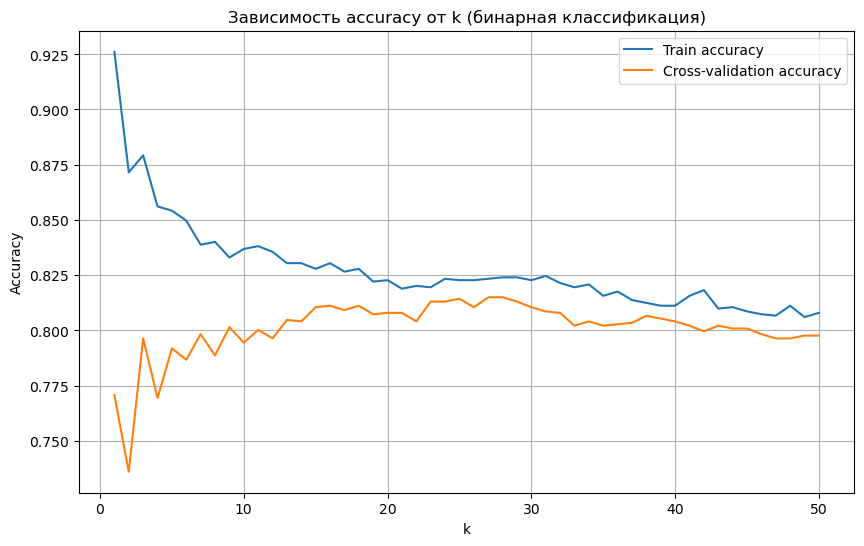

Оптимальное k по кросс-валидации: 27 с accuracy = 0.8150


In [13]:
X_scaled_all = scaler.fit_transform(X)
X_filt_all = X_scaled_all[:, [X.columns.get_loc(col) for col in selected_features]]

k_range = range(1, 51)
train_scores = []
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    cv_score = cross_val_score(knn, X_filt_all, y, cv=5, scoring='accuracy').mean()
    cv_scores.append(cv_score)
    knn.fit(X_filt_all, y)
    train_scores.append(knn.score(X_filt_all, y))

plt.figure(figsize=(10,6))
plt.plot(k_range, train_scores, label='Train accuracy')
plt.plot(k_range, cv_scores, label='Cross-validation accuracy')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('Зависимость accuracy от k (бинарная классификация)')
plt.legend()
plt.grid(True)
plt.show()

optimal_k = k_range[np.argmax(cv_scores)]
print(f'Оптимальное k по кросс-валидации: {optimal_k} с accuracy = {max(cv_scores):.4f}')

## 3. Многоклассовая классификация (house)

### 3.1 Подготовка данных для многоклассовой задачи

In [14]:
df_multi = data.copy()

cols_to_drop_multi = ['name', 'title', 'mother', 'father', 'heir', 'spouse',
                      'isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse', 'dateOfBirth']
df_multi.drop(columns=cols_to_drop_multi, inplace=True, errors='ignore')

df_multi['culture'].fillna('unknown', inplace=True)
df_multi['age'].fillna(df_multi['age'].median(), inplace=True)

# Целевая переменная - house. Удалим строки, где house отсутствует
df_multi = df_multi[df_multi['house'].notna()]

# Выберем только топ-5 самых частых домов
top5_houses = df_multi['house'].value_counts().head(5).index.tolist()
df_multi = df_multi[df_multi['house'].isin(top5_houses)]

print(df_multi['house'].value_counts())

house
House Frey         89
Night's Watch      88
House Stark        56
House Targaryen    40
House Lannister    36
Name: count, dtype: int64


In [15]:
df_multi = pd.get_dummies(df_multi, columns=['culture'], dummy_na=False)

X_multi = df_multi.drop('house', axis=1)
y_multi = df_multi['house']

le = LabelEncoder()
y_multi_enc = le.fit_transform(y_multi)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi_enc, test_size=0.2, random_state=42, stratify=y_multi_enc)

print(f'Размер обучающей выборки: {X_train_m.shape}')
print(f'Размер тестовой выборки: {X_test_m.shape}')

Размер обучающей выборки: (247, 28)
Размер тестовой выборки: (62, 28)


### 3.2 Балансировка классов
Посмотрим на распределение в обучающей выборке:

In [16]:
unique, counts = np.unique(y_train_m, return_counts=True)
for u, c in zip(unique, counts):
    print(f'{le.inverse_transform([u])[0]}: {c} ({c/len(y_train_m):.2f})')

House Frey: 71 (0.29)
House Lannister: 29 (0.12)
House Stark: 45 (0.18)
House Targaryen: 32 (0.13)
Night's Watch: 70 (0.28)


Дисбаланс есть: дом 'Targaryen' представлен значительно меньше. Применим SMOTE для мультикласса.

In [17]:
scaler_m = StandardScaler()
X_train_m_scaled = scaler_m.fit_transform(X_train_m)
X_test_m_scaled = scaler_m.transform(X_test_m)

smote = SMOTE(random_state=42)
X_train_m_res, y_train_m_res = smote.fit_resample(X_train_m_scaled, y_train_m)

print('После SMOTE:')
unique_res, counts_res = np.unique(y_train_m_res, return_counts=True)
for u, c in zip(unique_res, counts_res):
    print(f'{le.inverse_transform([u])[0]}: {c}')

После SMOTE:
House Frey: 71
House Lannister: 71
House Stark: 71
House Targaryen: 71
Night's Watch: 71


### 3.3 Классификация с k=5 (на сбалансированных и нормализованных данных)

In [18]:
knn_multi = KNeighborsClassifier(n_neighbors=5)
knn_multi.fit(X_train_m_res, y_train_m_res)
y_pred_multi = knn_multi.predict(X_test_m_scaled)

print('Accuracy:', accuracy_score(y_test_m, y_pred_multi))
print('Precision (macro):', precision_score(y_test_m, y_pred_multi, average='macro'))
print('Recall (macro):', recall_score(y_test_m, y_pred_multi, average='macro'))
print('F1-score (macro):', f1_score(y_test_m, y_pred_multi, average='macro'))
print('\nClassification Report:\n', classification_report(y_test_m, y_pred_multi, target_names=le.classes_))

Accuracy: 0.6612903225806451
Precision (macro): 0.687142857142857
Recall (macro): 0.6478354978354978
F1-score (macro): 0.655921052631579

Classification Report:
                  precision    recall  f1-score   support

     House Frey       0.65      0.72      0.68        18
House Lannister       0.25      0.43      0.32         7
    House Stark       1.00      0.73      0.84        11
House Targaryen       0.75      0.75      0.75         8
  Night's Watch       0.79      0.61      0.69        18

       accuracy                           0.66        62
      macro avg       0.69      0.65      0.66        62
   weighted avg       0.72      0.66      0.68        62



### 3.4 Отбор признаков для многоклассовой задачи

In [19]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=10)
selector.fit(X_train_m_scaled, y_train_m)

selected_indices = selector.get_support(indices=True)
selected_features_multi = X_train_m.columns[selected_indices].tolist()
print('Выбранные признаки:', selected_features_multi)

Выбранные признаки: ['book2', 'book3', 'book4', 'isMarried', 'isNoble', 'isAlive', 'culture_Northmen', 'culture_Valyrian', 'culture_Westerman', 'culture_unknown']


In [20]:
X_train_m_res_filt = X_train_m_res[:, selected_indices]
X_test_m_scaled_filt = X_test_m_scaled[:, selected_indices]

knn_multi_filt = KNeighborsClassifier(n_neighbors=5)
knn_multi_filt.fit(X_train_m_res_filt, y_train_m_res)
y_pred_multi_filt = knn_multi_filt.predict(X_test_m_scaled_filt)

print('После фильтрации признаков:')
print('Accuracy:', accuracy_score(y_test_m, y_pred_multi_filt))
print('Precision (macro):', precision_score(y_test_m, y_pred_multi_filt, average='macro'))
print('Recall (macro):', recall_score(y_test_m, y_pred_multi_filt, average='macro'))
print('F1-score (macro):', f1_score(y_test_m, y_pred_multi_filt, average='macro'))
print('\nClassification Report:\n', classification_report(y_test_m, y_pred_multi_filt, target_names=le.classes_))

После фильтрации признаков:
Accuracy: 0.6451612903225806
Precision (macro): 0.6524505494505495
Recall (macro): 0.6263347763347763
F1-score (macro): 0.6079580884232045

Classification Report:
                  precision    recall  f1-score   support

     House Frey       0.64      0.89      0.74        18
House Lannister       0.29      0.29      0.29         7
    House Stark       1.00      0.82      0.90        11
House Targaryen       0.46      0.75      0.57         8
  Night's Watch       0.88      0.39      0.54        18

       accuracy                           0.65        62
      macro avg       0.65      0.63      0.61        62
   weighted avg       0.71      0.65      0.64        62



**Вывод:**

После отбора признаков снова ухудшился результат как и при бинарной классификации. Возможно, следует иначе отбирать признаки

### 3.5 Подбор k для многоклассовой задачи (на отфильтрованных данных)

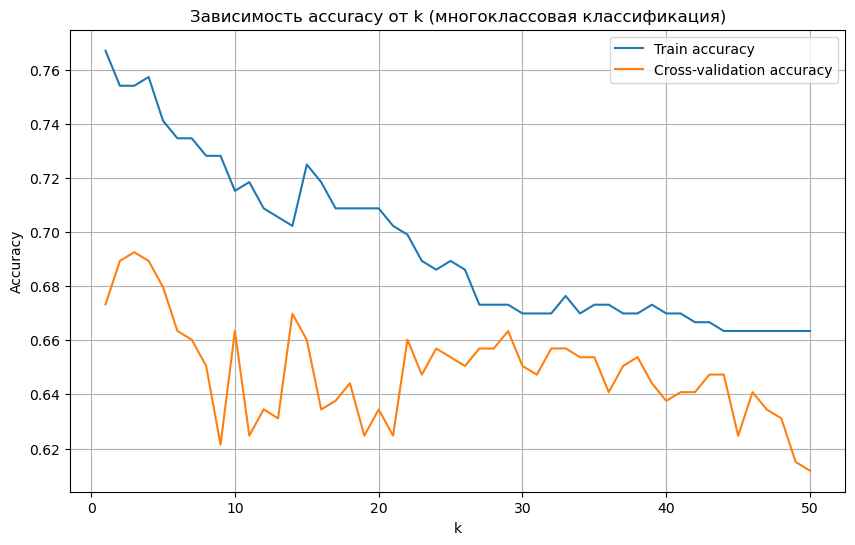

Оптимальное k: 3 с accuracy = 0.6925


In [21]:
X_multi_scaled_all = scaler_m.fit_transform(X_multi)
X_multi_filt_all = X_multi_scaled_all[:, selected_indices]
y_multi_all = y_multi_enc

k_range = range(1, 51)
cv_scores_multi = []
train_scores_multi = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    cv_score = cross_val_score(knn, X_multi_filt_all, y_multi_all, cv=5, scoring='accuracy').mean()
    cv_scores_multi.append(cv_score)
    knn.fit(X_multi_filt_all, y_multi_all)
    train_scores_multi.append(knn.score(X_multi_filt_all, y_multi_all))

plt.figure(figsize=(10,6))
plt.plot(k_range, train_scores_multi, label='Train accuracy')
plt.plot(k_range, cv_scores_multi, label='Cross-validation accuracy')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('Зависимость accuracy от k (многоклассовая классификация)')
plt.legend()
plt.grid(True)
plt.show()

optimal_k_multi = k_range[np.argmax(cv_scores_multi)]
print(f'Оптимальное k: {optimal_k_multi} с accuracy = {max(cv_scores_multi):.4f}')

### 3.6 Лучший классификатор и матрица ошибок

In [22]:
k_opt = optimal_k_multi
knn_final = KNeighborsClassifier(n_neighbors=k_opt)
knn_final.fit(X_train_m_res_filt, y_train_m_res)
y_pred_final = knn_final.predict(X_test_m_scaled_filt)

print(f'Итоговая модель с k={k_opt}:')
print('Accuracy:', accuracy_score(y_test_m, y_pred_final))
print('Classification Report:\n', classification_report(y_test_m, y_pred_final, target_names=le.classes_))

Итоговая модель с k=3:
Accuracy: 0.5
Classification Report:
                  precision    recall  f1-score   support

     House Frey       0.38      0.17      0.23        18
House Lannister       0.40      0.29      0.33         7
    House Stark       1.00      0.82      0.90        11
House Targaryen       0.50      0.75      0.60         8
  Night's Watch       0.39      0.61      0.48        18

       accuracy                           0.50        62
      macro avg       0.53      0.53      0.51        62
   weighted avg       0.51      0.50      0.48        62



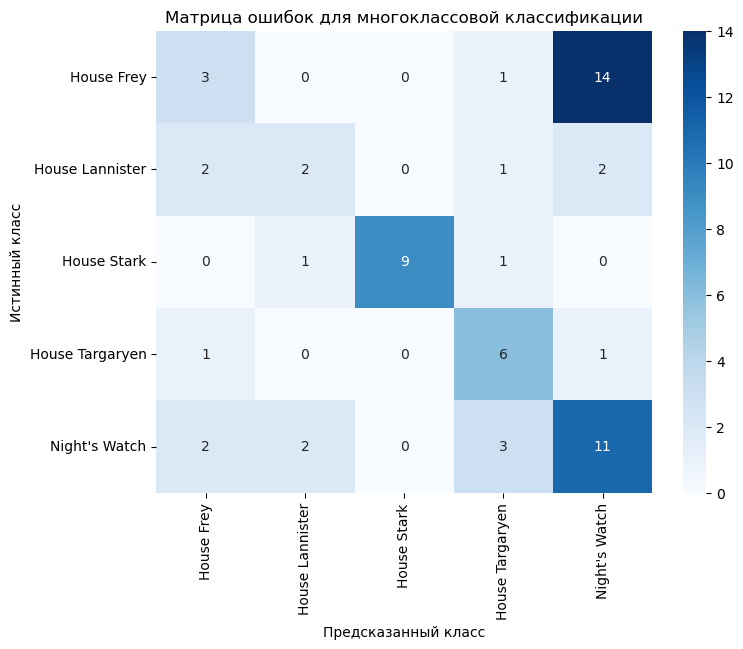

In [23]:
cm = confusion_matrix(y_test_m, y_pred_final)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок для многоклассовой классификации')
plt.show()